In [ ]:
# Cell 1 – Imports & Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os
warnings.filterwarnings("ignore")

CELL_COL    = "CO_DN"
RAW_FILE    = "../data/4G raw KPI Cell wise17th_June'26.xlsb"
OUTPUT_FILE = "../outputs/Cell_Health_Score_Report.xlsx"

def short_cell_name(co_dn):
    """
    Input : PLMN-PLMN/MRBTS-803406/LNBTS-803406/LNCEL-41
    Output: LNBTS-803406_LNCEL-41
    """
    parts = str(co_dn).split("/")
    if len(parts) >= 2:
        return f"{parts[-2]}_{parts[-1]}"
    return str(co_dn)

def safe_float(value):
    if value is None:
        return np.nan
    try:
        f = float(value)
        return np.nan if np.isinf(f) else f
    except (ValueError, TypeError):
        return np.nan

# KPI weights — must sum to 100
KPI_CONFIG = [
    {
        "col"      : "ERAB Drop Rate_Radio_Nokia_VeMr",
        "label"    : "Drop Rate",
        "weight"   : 30,
        "direction": "low",     # value should stay LOW
        "threshold": 0.5,
        "worst"    : 3.0,
    },
    {
        "col"      : "E2E Call Setup Success Rate_Nokia_VeMr",
        "label"    : "E2E CSSR",
        "weight"   : 25,
        "direction": "high",    # value should stay HIGH
        "threshold": 99.5,
        "worst"    : 90.0,
    },
    {
        "col"      : "VoLTE Call Setup Success Rate_Nokia_VeMr",
        "label"    : "VoLTE CSSR",
        "weight"   : 20,
        "direction": "high",
        "threshold": 99.5,
        "worst"    : 90.0,
    },
    {
        "col"      : "Average CQI_Nokia_VeMr",
        "label"    : "CQI",
        "weight"   : 15,
        "direction": "high",
        "threshold": 7.0,
        "worst"    : 4.0,
    },
    {
        "col"      : "Nokia_LTE_DL_User_Throughput_Mbps",
        "label"    : "Avg Thpr",
        "weight"   : 10,
        "direction": "high",
        "threshold": 3.0,
        "worst"    : 0.5,
    },
]

total_weight = sum(k["weight"] for k in KPI_CONFIG)
print(f"Total weight = {total_weight}  "
      f"({'✅ correct' if total_weight == 100 else '❌ must be 100'})")
print("✅ Setup done")

Total weight = 100  (✅ correct)
✅ Setup done


In [3]:
# Cell 2 – Load sheet names
import pyxlsb

with pyxlsb.open_workbook(RAW_FILE) as wb:
    sheet_names = wb.sheets

print(f"Found {len(sheet_names)} day-sheets:")
for i, s in enumerate(sheet_names, 1):
    print(f"  {i:2d}.  {s}")

Found 17 day-sheets:
   1.  1st June_Cell Wise_4G
   2.  2nd June_Cell Wise_4G
   3.  3rd June_Cell Wise_4G
   4.  4th June_Cell Wise_4G
   5.  5th June_Cell Wise_4G
   6.  6th June_Cell Wise_4G
   7.  7th June_Cell Wise_4G
   8.  8th June_Cell Wise_4G
   9.  9th June_Cell Wise_4G
  10.  10th June_Cell Wise_4G
  11.  11th June_Cell Wise_4G
  12.  12th June_Cell Wise_4G
  13.  13th June_Cell Wise_4G
  14.  14th June_Cell Wise_4G
  15.  15th June_Cell Wise_4G
  16.  16th June_Cell Wise_4G
  17.  17th June_Cell Wise_4G


In [4]:
# Cell 3 – Health score calculation functions

def compute_kpi_penalty(value, cfg):
    """
    Linear interpolation between threshold and worst.
    Returns penalty points (0 to weight).
    """
    value = safe_float(value)

    if np.isnan(value):
        return cfg["weight"] * 0.5    # missing = 50% penalty

    w         = cfg["weight"]
    threshold = cfg["threshold"]
    worst     = cfg["worst"]

    if cfg["direction"] == "low":     # lower is better (Drop Rate)
        if value <= threshold:
            return 0
        penalty_ratio = (value - threshold) / (worst - threshold)
    else:                             # higher is better (CQI, CSSR)
        if value >= threshold:
            return 0
        penalty_ratio = (threshold - value) / (threshold - worst)

    penalty_ratio = min(1.0, max(0.0, penalty_ratio))
    return round(w * penalty_ratio, 2)


def compute_health_score(row):
    """Health Score = 100 - sum of all KPI penalties."""
    total_penalty = 0
    breakdown     = {}

    for cfg in KPI_CONFIG:
        col     = cfg["col"]
        value   = row.get(col, np.nan)
        penalty = compute_kpi_penalty(value, cfg)
        total_penalty           += penalty
        breakdown[cfg["label"]]  = round(penalty, 2)

    score = round(max(0, 100 - total_penalty), 1)
    return score, breakdown


def get_grade(score):
    if score >= 85: return "Healthy",   "🟢"
    if score >= 65: return "Warning",   "🟡"
    if score >= 40: return "Degraded",  "🟠"
    return                 "Critical",  "🔴"


# Test
test_row = {
    "ERAB Drop Rate_Radio_Nokia_VeMr"          : "0.3",
    "E2E Call Setup Success Rate_Nokia_VeMr"   : 96.0,
    "VoLTE Call Setup Success Rate_Nokia_VeMr" : 98.0,
    "Average CQI_Nokia_VeMr"                   : 6.5,
    "Nokia_LTE_DL_User_Throughput_Mbps"        : None,
}
score, breakdown = compute_health_score(test_row)
grade, icon      = get_grade(score)
print(f"Test score : {score}  →  {icon} {grade}")
print(f"Breakdown  : {breakdown}")

Test score : 82.0  →  🟡 Warning
Breakdown  : {'Drop Rate': 0, 'E2E CSSR': 8.33, 'VoLTE CSSR': 2.22, 'CQI': 2.5, 'Avg Thpr': 5.0}


In [5]:
# Cell 4 – Compute health scores for all days (MEMORY OPTIMIZED)

all_days_scores = []

# Only the columns we actually need to keep per day
KEEP_BASE_COLS = [CELL_COL, "Short_Cell", "Day"]
KPI_PRESENT    = [cfg["col"] for cfg in KPI_CONFIG]

for sheet in sheet_names:
    print(f"  Processing: {sheet[:35]}")
    df_day = pd.read_excel(RAW_FILE, sheet_name=sheet, engine="pyxlsb")
    df_day = df_day.reset_index(drop=True)

    if df_day.empty or CELL_COL not in df_day.columns:
        print(f"    Skipping — empty or no {CELL_COL}")
        continue

    df_day["Short_Cell"] = df_day[CELL_COL].apply(short_cell_name)

    # ── Vectorized penalty computation per KPI ──
    penalty_cols = {}
    kpi_values   = {}   # keep raw KPI values too, needed for Excel later

    for cfg in KPI_CONFIG:
        col = cfg["col"]
        if col not in df_day.columns:
            continue
        numeric = pd.to_numeric(df_day[col], errors="coerce")
        kpi_values[col] = numeric    # store raw values

        w, threshold, worst, direction = (
            cfg["weight"], cfg["threshold"],
            cfg["worst"], cfg["direction"]
        )

        if direction == "low":
            ratio = (numeric - threshold) / (worst - threshold)
        else:
            ratio = (threshold - numeric) / (threshold - worst)

        ratio   = ratio.clip(lower=0, upper=1)
        penalty = (ratio * w).round(2)
        penalty = penalty.where(numeric.notna(), w * 0.5)

        penalty_cols[f"Penalty_{cfg['label']}"] = penalty

    health_score = (100 - pd.DataFrame(penalty_cols).sum(axis=1)).clip(lower=0).round(1)

    grade = pd.cut(
        health_score,
        bins   = [-1, 39.999, 64.999, 84.999, 100],
        labels = ["Critical", "Degraded", "Warning", "Healthy"]
    ).astype(str)

    grade_icon_map = {
        "Healthy": "🟢", "Warning": "🟡",
        "Degraded": "🟠", "Critical": "🔴"
    }

    # ── Build SLIM DataFrame — only what's needed downstream ──
    slim = pd.DataFrame({
        CELL_COL      : df_day[CELL_COL],
        "Short_Cell"  : df_day["Short_Cell"],
        "Day"         : sheet,
        "Health_Score": health_score,
        "Grade"       : grade,
        "Icon"        : grade.map(grade_icon_map),
    })

    # Add raw KPI values
    for col, vals in kpi_values.items():
        slim[col] = vals.round(3)

    # Add penalty columns
    for pname, pvals in penalty_cols.items():
        slim[pname] = pvals

    all_days_scores.append(slim)

    avg  = slim["Health_Score"].mean()
    crit = (slim["Grade"] == "Critical").sum()
    print(f"    avg score={avg:.1f}  critical={crit}")

    # Free memory from the full raw df_day immediately
    del df_day

master_scores = pd.concat(all_days_scores, ignore_index=True)
print(f"\n✅ Scored {len(master_scores):,} cell-day records "
      f"across {len(all_days_scores)} days")
print(f"   Memory usage: {master_scores.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

  Processing: 1st June_Cell Wise_4G
    avg score=98.9  critical=8
  Processing: 2nd June_Cell Wise_4G
    avg score=98.9  critical=7
  Processing: 3rd June_Cell Wise_4G
    avg score=98.8  critical=7
  Processing: 4th June_Cell Wise_4G
    avg score=98.7  critical=5
  Processing: 5th June_Cell Wise_4G
    avg score=98.8  critical=5
  Processing: 6th June_Cell Wise_4G
    avg score=98.8  critical=6
  Processing: 7th June_Cell Wise_4G
    avg score=98.7  critical=9
  Processing: 8th June_Cell Wise_4G
    avg score=98.8  critical=7
  Processing: 9th June_Cell Wise_4G
    avg score=98.3  critical=4
  Processing: 10th June_Cell Wise_4G
    avg score=98.6  critical=11
  Processing: 11th June_Cell Wise_4G
    avg score=98.6  critical=7
  Processing: 12th June_Cell Wise_4G
    avg score=98.6  critical=7
  Processing: 13th June_Cell Wise_4G
    avg score=98.2  critical=8
  Processing: 14th June_Cell Wise_4G
    avg score=98.7  critical=5
  Processing: 15th June_Cell Wise_4G
    avg score=98.6 

In [6]:
# Cell 5 – Chronic cell tracker (using Short_Cell)

from collections import defaultdict

cell_tracker = defaultdict(lambda: {"scores": [], "grades": [], "days": []})

for sheet in sheet_names:
    day_df = master_scores[master_scores["Day"] == sheet]
    for _, row in day_df.iterrows():
        cell = row["Short_Cell"]
        cell_tracker[cell]["scores"].append(row["Health_Score"])
        cell_tracker[cell]["grades"].append(row["Grade"])
        cell_tracker[cell]["days"].append(sheet)

chronic_rows = []
for cell, data in cell_tracker.items():
    scores      = data["scores"]
    grades      = data["grades"]
    days_bad    = sum(1 for g in grades if g in ["Critical", "Degraded"])
    total_days  = len(scores)
    persistence = round(days_bad / total_days * 100, 1)
    avg_score   = round(np.mean(scores), 1)
    min_score   = round(min(scores), 1)

    if days_bad >= 3:
        if persistence >= 80:   chronic_type = "Persistent"
        elif persistence >= 40: chronic_type = "Recurring"
        else:                   chronic_type = "Intermittent"

        chronic_rows.append({
            "Short_Cell"       : cell,
            "Avg_Health_Score" : avg_score,
            "Min_Health_Score" : min_score,
            "Days_Degraded"    : days_bad,
            "Total_Days"       : total_days,
            "Persistence_%"    : persistence,
            "Chronic_Type"     : chronic_type,
            "Action"           : (
                "🚨 Dispatch Field Team"  if persistence >= 80 else
                "⚠️  Schedule Inspection" if persistence >= 40 else
                "👁️  Monitor Closely"
            )
        })

chronic_df = pd.DataFrame(chronic_rows).sort_values(
    ["Days_Degraded", "Avg_Health_Score"],
    ascending=[False, True]
).reset_index(drop=True)

print(f"Chronic bad cells found: {len(chronic_df)}")
print(f"\n  Persistent   (≥80%): "
      f"{len(chronic_df[chronic_df['Chronic_Type']=='Persistent'])}")
print(f"  Recurring    (≥40%): "
      f"{len(chronic_df[chronic_df['Chronic_Type']=='Recurring'])}")
print(f"  Intermittent (<40%): "
      f"{len(chronic_df[chronic_df['Chronic_Type']=='Intermittent'])}")
chronic_df.head(10)

Chronic bad cells found: 739

  Persistent   (≥80%): 217
  Recurring    (≥40%): 174
  Intermittent (<40%): 348


,Short_Cell,Avg_Health_Score,Min_Health_Score,Days_Degraded,Total_Days,Persistence_%,Chronic_Type,Action
0,LNBTS-803213_LNCEL-43,40.6,25.0,17,17,100.0,Persistent,🚨 Dispatch Field Team
1,LNBTS-802870_LNCEL-43,41.0,25.0,17,17,100.0,Persistent,🚨 Dispatch Field Team
2,LNBTS-804916_LNCEL-43,41.5,30.9,17,17,100.0,Persistent,🚨 Dispatch Field Team
3,LNBTS-802685_LNCEL-41,42.3,38.9,17,17,100.0,Persistent,🚨 Dispatch Field Team
4,LNBTS-804916_LNCEL-42,42.3,40.2,17,17,100.0,Persistent,🚨 Dispatch Field Team
5,LNBTS-802288_LNCEL-41,44.4,28.2,17,17,100.0,Persistent,🚨 Dispatch Field Team
6,LNBTS-803213_LNCEL-42,45.5,38.9,17,17,100.0,Persistent,🚨 Dispatch Field Team
7,LNBTS-804603_LNCEL-41,45.9,42.8,17,17,100.0,Persistent,🚨 Dispatch Field Team
8,LNBTS-801897_LNCEL-43,46.7,42.1,17,17,100.0,Persistent,🚨 Dispatch Field Team
9,LNBTS-802288_LNCEL-43,47.6,37.8,17,17,100.0,Persistent,🚨 Dispatch Field Team


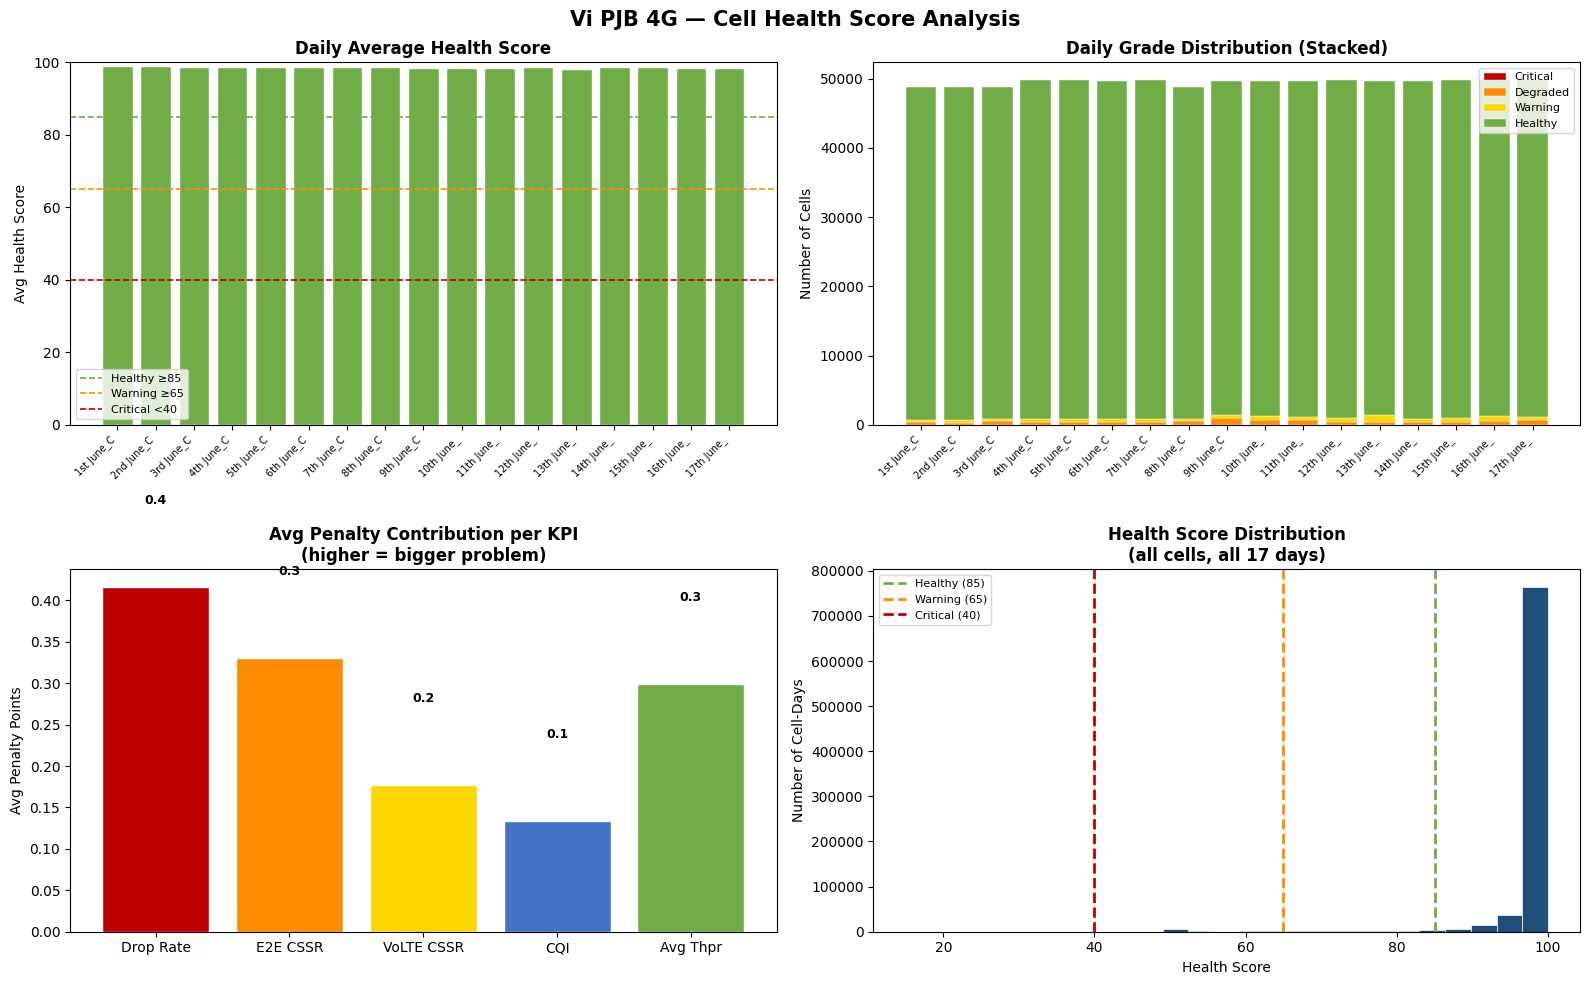

✅ Chart saved → outputs/health_score_analysis.png


In [7]:
# Cell 6 – 4-panel health score analysis chart

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Vi PJB 4G — Cell Health Score Analysis",
             fontsize=15, fontweight="bold")

# ── Plot 1: Daily average health score trend ──
ax1       = axes[0, 0]
daily_avg = master_scores.groupby("Day")["Health_Score"].mean().reindex(sheet_names)
bar_colors = [
    "#C00000" if v < 65 else "#FF8C00" if v < 85 else "#70AD47"
    for v in daily_avg.values
]
ax1.bar(range(len(daily_avg)), daily_avg.values,
        color=bar_colors, edgecolor="white")
ax1.set_xticks(range(len(daily_avg)))
ax1.set_xticklabels([d[:10] for d in daily_avg.index],
                    rotation=45, ha="right", fontsize=7)
ax1.axhline(85, color="#70AD47", linestyle="--", linewidth=1.2, label="Healthy ≥85")
ax1.axhline(65, color="#FF8C00", linestyle="--", linewidth=1.2, label="Warning ≥65")
ax1.axhline(40, color="#C00000", linestyle="--", linewidth=1.2, label="Critical <40")
ax1.set_title("Daily Average Health Score", fontweight="bold")
ax1.set_ylabel("Avg Health Score")
ax1.set_ylim(0, 100)
ax1.legend(fontsize=8)

# ── Plot 2: Grade distribution stacked bar ──
ax2 = axes[0, 1]
grade_order  = ["Critical", "Degraded", "Warning", "Healthy"]
grade_colors = {"Critical":"#C00000","Degraded":"#FF8C00",
                "Warning":"#FFD700","Healthy":"#70AD47"}

bottom_vals = np.zeros(len(sheet_names))
for grade in grade_order:
    day_counts = [
        len(master_scores[
            (master_scores["Day"] == s) &
            (master_scores["Grade"] == grade)
        ])
        for s in sheet_names
    ]
    ax2.bar(range(len(sheet_names)), day_counts,
            bottom=bottom_vals, color=grade_colors[grade],
            label=grade, edgecolor="white", linewidth=0.3)
    bottom_vals += np.array(day_counts)

ax2.set_xticks(range(len(sheet_names)))
ax2.set_xticklabels([d[:10] for d in sheet_names],
                    rotation=45, ha="right", fontsize=7)
ax2.set_title("Daily Grade Distribution (Stacked)", fontweight="bold")
ax2.set_ylabel("Number of Cells")
ax2.legend(fontsize=8, loc="upper right")

# ── Plot 3: Average penalty per KPI ──
ax3          = axes[1, 0]
penalty_cols = [f"Penalty_{cfg['label']}" for cfg in KPI_CONFIG]
penalty_cols = [c for c in penalty_cols if c in master_scores.columns]
kpi_labels   = [cfg["label"] for cfg in KPI_CONFIG
                if f"Penalty_{cfg['label']}" in penalty_cols]
avg_penalties = master_scores[penalty_cols].mean().values
bar_colors3  = ["#C00000","#FF8C00","#FFD700","#4472C4","#70AD47"]

bars = ax3.bar(kpi_labels, avg_penalties,
               color=bar_colors3[:len(kpi_labels)],
               edgecolor="white")
ax3.set_title("Avg Penalty Contribution per KPI\n(higher = bigger problem)",
              fontweight="bold")
ax3.set_ylabel("Avg Penalty Points")
for bar, val in zip(bars, avg_penalties):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.1,
             f"{val:.1f}", ha="center", fontsize=9, fontweight="bold")

# ── Plot 4: Health score histogram ──
ax4 = axes[1, 1]
ax4.hist(master_scores["Health_Score"], bins=25,
         color="#1F4E79", edgecolor="white", linewidth=0.5)
ax4.axvline(85, color="#70AD47", linestyle="--", linewidth=2, label="Healthy (85)")
ax4.axvline(65, color="#FF8C00", linestyle="--", linewidth=2, label="Warning (65)")
ax4.axvline(40, color="#C00000", linestyle="--", linewidth=2, label="Critical (40)")
ax4.set_title("Health Score Distribution\n(all cells, all 17 days)",
              fontweight="bold")
ax4.set_xlabel("Health Score")
ax4.set_ylabel("Number of Cell-Days")
ax4.legend(fontsize=8)

plt.tight_layout()
plt.savefig("../outputs/health_score_analysis.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved → outputs/health_score_analysis.png")

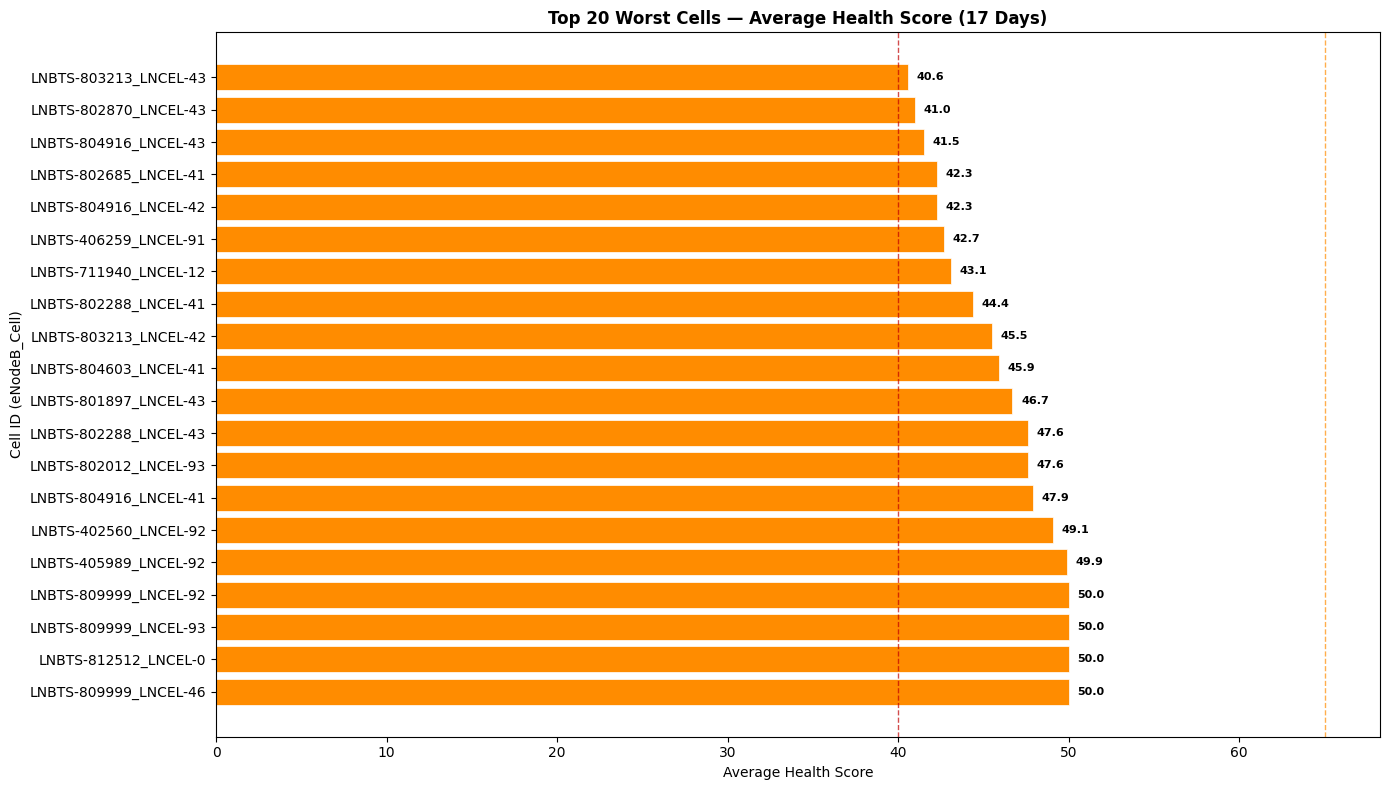

✅ Saved → outputs/health_worst_cells.png


In [8]:
# Cell 7 – Top 20 worst cells by average health score

worst_cells = (
    master_scores.groupby("Short_Cell")["Health_Score"]
    .agg(["mean", "min", "count"])
    .reset_index()
    .rename(columns={
        "mean" : "Avg_Score",
        "min"  : "Min_Score",
        "count": "Days_Tracked"
    })
    .sort_values("Avg_Score")
    .head(20)
)
worst_cells["Avg_Score"] = worst_cells["Avg_Score"].round(1)

fig, ax = plt.subplots(figsize=(14, 8))
colors  = [
    "#C00000" if v < 40 else "#FF8C00" if v < 65 else "#FFD700"
    for v in worst_cells["Avg_Score"]
]
bars = ax.barh(
    worst_cells["Short_Cell"][::-1],
    worst_cells["Avg_Score"][::-1],
    color=colors[::-1], edgecolor="white", linewidth=0.5
)
for bar, val in zip(bars, worst_cells["Avg_Score"][::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{val}", va="center", fontsize=8, fontweight="bold")

ax.axvline(40, color="#C00000", linestyle="--", linewidth=1, alpha=0.7)
ax.axvline(65, color="#FF8C00", linestyle="--", linewidth=1, alpha=0.7)
ax.set_title("Top 20 Worst Cells — Average Health Score (17 Days)",
             fontweight="bold", fontsize=12)
ax.set_xlabel("Average Health Score")
ax.set_ylabel("Cell ID (eNodeB_Cell)")
plt.tight_layout()
plt.savefig("../outputs/health_worst_cells.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved → outputs/health_worst_cells.png")

In [9]:
# Cell 8 – Export Cell_Health_Score_Report.xlsx (OPTIMIZED)
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

OUTPUT_FILE = "../outputs/Cell_Health_Score_Report.xlsx"

TTL_FILL  = PatternFill("solid", fgColor="0D2137")
TTL_FONT  = Font(bold=True, color="FFFFFF", name="Arial", size=12)
HDR_FILL  = PatternFill("solid", fgColor="1F4E79")
HDR_FONT  = Font(bold=True, color="FFFFFF", name="Arial", size=10)
ALT_FILL  = PatternFill("solid", fgColor="D6E4F0")
BODY_FONT = Font(name="Arial", size=9)
THIN      = Side(style="thin", color="BFBFBF")
BORDER    = Border(left=THIN, right=THIN, top=THIN, bottom=THIN)
CENTER    = Alignment(horizontal="center", vertical="center", wrap_text=True)
LEFT      = Alignment(horizontal="left",   vertical="center", wrap_text=True)
RED_FONT  = Font(name="Arial", size=9, color="C00000", bold=True)

GRADE_FILLS = {
    "Healthy" : PatternFill("solid", fgColor="E2EFDA"),
    "Warning" : PatternFill("solid", fgColor="FFEB9C"),
    "Degraded": PatternFill("solid", fgColor="FFDDC1"),
    "Critical": PatternFill("solid", fgColor="FFC7CE"),
}
GRADE_FONTS = {
    "Healthy" : Font(name="Arial", size=9, color="375623", bold=True),
    "Warning" : Font(name="Arial", size=9, color="9C5700", bold=True),
    "Degraded": Font(name="Arial", size=9, color="C55A11", bold=True),
    "Critical": Font(name="Arial", size=9, color="C00000", bold=True),
}
ACTION_FILLS = {
    "Persistent"  : PatternFill("solid", fgColor="FFC7CE"),
    "Recurring"   : PatternFill("solid", fgColor="FFDDC1"),
    "Intermittent": PatternFill("solid", fgColor="FFEB9C"),
}

def write_title_header(ws, title, headers):
    ncols = len(headers)
    ws.append([title] + [""] * (ncols - 1))
    ws.merge_cells(f"A1:{get_column_letter(ncols)}1")
    ws["A1"].fill = TTL_FILL; ws["A1"].font = TTL_FONT
    ws["A1"].alignment = CENTER; ws["A1"].border = BORDER
    ws.append(headers)
    for cell in ws[2]:
        cell.fill = HDR_FILL; cell.font = HDR_FONT
        cell.alignment = CENTER; cell.border = BORDER
    ws.row_dimensions[1].height = 22
    ws.row_dimensions[2].height = 28

def apply_base_style(ws, start_row, end_row, ncols):
    for i in range(start_row, end_row + 1):
        fill = ALT_FILL if i % 2 == 0 else None
        for j in range(1, ncols + 1):
            c = ws.cell(row=i, column=j)
            c.font = BODY_FONT; c.border = BORDER
            c.alignment = LEFT if j == 1 else CENTER
            if fill: c.fill = fill

wb = Workbook()
wb.remove(wb.active)

# ── Sheet 1: Daily Summary ──
print("Writing Daily Summary...")
sw = wb.create_sheet("Daily Summary")
write_title_header(sw,
    "Daily Health Score Summary — Vi PJB 4G",
    ["Day", "Total Cells", "🟢 Healthy", "🟡 Warning",
     "🟠 Degraded", "🔴 Critical", "Avg Score", "Min Score"]
)

for sheet in sheet_names:
    day_df = master_scores[master_scores["Day"] == sheet]
    if day_df.empty: continue
    gc = day_df["Grade"].value_counts()
    sw.append([
        sheet, len(day_df),
        gc.get("Healthy",  0), gc.get("Warning",  0),
        gc.get("Degraded", 0), gc.get("Critical", 0),
        round(day_df["Health_Score"].mean(), 1),
        round(day_df["Health_Score"].min(),  1),
    ])

apply_base_style(sw, 3, 3 + len(sheet_names) - 1, 8)
for col, w in zip("ABCDEFGH", [32,13,12,12,12,12,12,12]):
    sw.column_dimensions[col].width = w
sw.freeze_panes = "A3"

# ── Sheets 2–18: Per-day sheets ──
DISPLAY_COLS = (
    ["Short_Cell", "Health_Score", "Grade"] +
    [cfg["col"] for cfg in KPI_CONFIG if cfg["col"] in master_scores.columns] +
    [f"Penalty_{cfg['label']}" for cfg in KPI_CONFIG
     if f"Penalty_{cfg['label']}" in master_scores.columns]
)
HEADERS = (
    ["Cell ID (eNodeB_Cell)", "Health Score", "Grade"] +
    [cfg["label"] for cfg in KPI_CONFIG if cfg["col"] in master_scores.columns] +
    [f"Penalty: {cfg['label']} (/{cfg['weight']}pt)" for cfg in KPI_CONFIG
     if f"Penalty_{cfg['label']}" in master_scores.columns]
)

score_col_idx = DISPLAY_COLS.index("Health_Score") + 1
grade_col_idx = DISPLAY_COLS.index("Grade") + 1

kpi_col_indices = {
    cfg["col"]: DISPLAY_COLS.index(cfg["col"]) + 1
    for cfg in KPI_CONFIG if cfg["col"] in DISPLAY_COLS
}

for sheet in sheet_names:
    print(f"  Writing sheet: {sheet[:35]}")
    day_df = master_scores[master_scores["Day"] == sheet].copy()
    if day_df.empty: continue

    day_df = day_df.sort_values("Health_Score", ascending=True).reset_index(drop=True)

    breach_arrays = {}
    for cfg in KPI_CONFIG:
        col = cfg["col"]
        if col not in day_df.columns: continue
        numeric = pd.to_numeric(day_df[col], errors="coerce").values
        if cfg["direction"] == "low":
            breach_arrays[col] = numeric > cfg["threshold"]
        else:
            breach_arrays[col] = numeric < cfg["threshold"]

    grades_arr = day_df["Grade"].values
    safe  = sheet[:31].replace("/","-").replace(":","-")
    ws    = wb.create_sheet(title=safe)
    ncols = len(DISPLAY_COLS)
    write_title_header(ws, f"Cell Health Scores — {sheet}", HEADERS)

    display_data = []
    for idx in range(len(day_df)):
        row_vals = []
        for c in DISPLAY_COLS:
            v = day_df.iloc[idx][c] if c in day_df.columns else ""
            if hasattr(v, "item"): v = v.item()
            row_vals.append(v)
        display_data.append(row_vals)

    for row_vals in display_data:
        ws.append(row_vals)

    for i, (row_vals, grade) in enumerate(zip(display_data, grades_arr), start=3):
        base_fill = ALT_FILL if i % 2 == 0 else None
        for j in range(1, ncols + 1):
            cell = ws.cell(row=i, column=j)
            cell.font = BODY_FONT; cell.border = BORDER
            cell.alignment = LEFT if j == 1 else CENTER
            if base_fill: cell.fill = base_fill

        g_fill = GRADE_FILLS.get(grade, ALT_FILL)
        g_font = GRADE_FONTS.get(grade, BODY_FONT)
        ws.cell(row=i, column=score_col_idx).fill = g_fill
        ws.cell(row=i, column=score_col_idx).font = g_font
        ws.cell(row=i, column=grade_col_idx).fill = g_fill
        ws.cell(row=i, column=grade_col_idx).font = g_font

        data_idx = i - 3
        for cfg in KPI_CONFIG:
            col = cfg["col"]
            if col not in breach_arrays: continue
            if breach_arrays[col][data_idx]:
                ws.cell(row=i, column=kpi_col_indices[col]).font = RED_FONT

    ws.column_dimensions["A"].width = 28
    ws.column_dimensions["B"].width = 14
    ws.column_dimensions["C"].width = 12
    for idx in range(4, ncols + 1):
        ws.column_dimensions[get_column_letter(idx)].width = 16
    ws.freeze_panes = "A3"

# ── Sheet 19: Chronic Cells ──
print("Writing Chronic Cells...")
cs = wb.create_sheet("Chronic Cells")
c_cols = ["Short_Cell", "Avg_Health_Score", "Min_Health_Score",
          "Days_Degraded", "Total_Days", "Persistence_%",
          "Chronic_Type", "Action"]
c_hdrs = ["Cell ID (eNodeB_Cell)", "Avg Health Score", "Min Health Score",
          "Days Degraded", "Total Days", "Persistence %",
          "Chronic Type", "Recommended Action"]

write_title_header(cs, "Chronic Degraded Cells — Vi PJB 4G", c_hdrs)

for _, row in chronic_df[c_cols].iterrows():
    cs.append([row[c] for c in c_cols])

apply_base_style(cs, 3, 3 + len(chronic_df) - 1, len(c_cols))
for i, (_, row) in enumerate(chronic_df.iterrows(), start=3):
    fill = ACTION_FILLS.get(row["Chronic_Type"], ALT_FILL)
    for cell in cs[i]:
        cell.fill = fill

for col, w in zip("ABCDEFGH", [28,16,16,14,12,14,16,28]):
    cs.column_dimensions[col].width = w
cs.freeze_panes = "A3"

print("Saving...")
os.makedirs(os.path.dirname(OUTPUT_FILE), exist_ok=True)
wb.save(OUTPUT_FILE)
print(f"\n✅ Report saved → {OUTPUT_FILE}")
print(f"   Sheets: Daily Summary + {len(sheet_names)} day sheets + Chronic Cells")

Writing Daily Summary...
  Writing sheet: 1st June_Cell Wise_4G
  Writing sheet: 2nd June_Cell Wise_4G
  Writing sheet: 3rd June_Cell Wise_4G
  Writing sheet: 4th June_Cell Wise_4G
  Writing sheet: 5th June_Cell Wise_4G
  Writing sheet: 6th June_Cell Wise_4G
  Writing sheet: 7th June_Cell Wise_4G
  Writing sheet: 8th June_Cell Wise_4G
  Writing sheet: 9th June_Cell Wise_4G
  Writing sheet: 10th June_Cell Wise_4G
  Writing sheet: 11th June_Cell Wise_4G
  Writing sheet: 12th June_Cell Wise_4G
  Writing sheet: 13th June_Cell Wise_4G
  Writing sheet: 14th June_Cell Wise_4G
  Writing sheet: 15th June_Cell Wise_4G
  Writing sheet: 16th June_Cell Wise_4G
  Writing sheet: 17th June_Cell Wise_4G
Writing Chronic Cells...
Saving...

✅ Report saved → ../outputs/Cell_Health_Score_Report.xlsx
   Sheets: Daily Summary + 17 day sheets + Chronic Cells


In [10]:
# Cell 9 – Console preview

print("=" * 60)
print("NETWORK OVERVIEW — ALL 17 DAYS")
print("=" * 60)
grade_counts = master_scores["Grade"].value_counts()
total        = len(master_scores)
for grade, icon in [("Critical","🔴"),("Degraded","🟠"),
                    ("Warning","🟡"),("Healthy","🟢")]:
    count = grade_counts.get(grade, 0)
    pct   = round(count / total * 100, 1)
    bar   = "█" * int(pct / 2)
    print(f"  {icon} {grade:<10} {count:>5} cell-days  ({pct:>5}%)  {bar}")

print(f"\n{'='*60}")
print("TOP 10 WORST CELLS — LOWEST AVG HEALTH SCORE")
print("=" * 60)
worst10 = worst_cells.head(10)
print(worst10[["Short_Cell","Avg_Score","Min_Score","Days_Tracked"]]
      .to_string(index=False))

print(f"\n{'='*60}")
print("CHRONIC CELLS — FIELD DISPATCH REQUIRED")
print("=" * 60)
dispatch = chronic_df[chronic_df["Chronic_Type"] == "Persistent"]
if dispatch.empty:
    print("  ✅ No persistent cells found")
else:
    print(f"  {len(dispatch)} cells need immediate attention:\n")
    print(dispatch[["Short_Cell", "Avg_Health_Score", "Days_Degraded",
                    "Persistence_%", "Action"]].to_string(index=False))

print(f"\n{'='*60}")
print("DAILY TREND — BEST AND WORST DAYS")
print("=" * 60)
daily_avg = master_scores.groupby("Day")["Health_Score"].mean().reindex(sheet_names)
best_day  = daily_avg.idxmax()
worst_day = daily_avg.idxmin()
print(f"  🟢 Best day  : {best_day[:30]}  (avg score = {daily_avg[best_day]:.1f})")
print(f"  🔴 Worst day : {worst_day[:30]}  (avg score = {daily_avg[worst_day]:.1f})")

NETWORK OVERVIEW — ALL 17 DAYS
  🔴 Critical     114 cell-days  (  0.0%)  
  🟠 Degraded    8393 cell-days  (  1.0%)  
  🟡 Warning     8526 cell-days  (  1.0%)  
  🟢 Healthy    825092 cell-days  ( 98.0%)  █████████████████████████████████████████████████

TOP 10 WORST CELLS — LOWEST AVG HEALTH SCORE
           Short_Cell  Avg_Score  Min_Score  Days_Tracked
LNBTS-803213_LNCEL-43       40.6       25.0            17
LNBTS-802870_LNCEL-43       41.0       25.0            17
LNBTS-804916_LNCEL-43       41.5       30.9            17
LNBTS-802685_LNCEL-41       42.3       38.9            17
LNBTS-804916_LNCEL-42       42.3       40.2            17
LNBTS-406259_LNCEL-91       42.7       29.6            17
LNBTS-711940_LNCEL-12       43.1       15.0            17
LNBTS-802288_LNCEL-41       44.4       28.2            17
LNBTS-803213_LNCEL-42       45.5       38.9            17
LNBTS-804603_LNCEL-41       45.9       42.8            17

CHRONIC CELLS — FIELD DISPATCH REQUIRED
  217 cells need immed